# **Imports**

In [1]:
import scipy.io as scio
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as scio
from sklearn.model_selection import train_test_split

# **Load Dataset**

In [3]:
MAT_PATH = "Subject1_Temporal_Feature.mat"

data = scio.loadmat(MAT_PATH)
feature_dataset = data["feature_dataset"]
feature_headers = data["feature_headers"]
print(f"feature_dataset Shape :{feature_dataset.shape}")
print(f"feature_headers Shape :{feature_headers.shape}")

features = feature_dataset[:, :64].astype(np.float32)
BG = feature_dataset[:, 64].astype(np.float32)
PKL_ID = feature_dataset[:, 65].astype(np.float32)

print(f"Features Shape : {features.shape}")
print(f"Glucose Shape : {BG.shape}")
print(f"PKL_ID Shape : {PKL_ID.shape}")


feature_dataset Shape :(29428, 66)
feature_headers Shape :(66,)
Features Shape : (29428, 64)
Glucose Shape : (29428,)
PKL_ID Shape : (29428,)


# **Train-Test split (PKL-based)**

### Create representative glucose for each PKL

In [4]:
pkl_glucose = []

unique_pkl_ids = np.unique(PKL_ID)

for current_pkl in unique_pkl_ids:
    glucose_value = BG[PKL_ID == current_pkl][0]
    pkl_glucose.append(glucose_value)
pkl_glucose = np.array(pkl_glucose)

### Create glucose bins
Clinical glucose bins


*   Bin 0 : Hypoglycemia        (<70)
*   Bin 1 : Normal              (70-140)
*   Bin 2 : High                (140-180)
*   Bin 3 : Very High           (>180)

In [5]:
bg_bins = np.digitize(pkl_glucose, bins=[70, 140, 180])

#### Distribution of BG Values

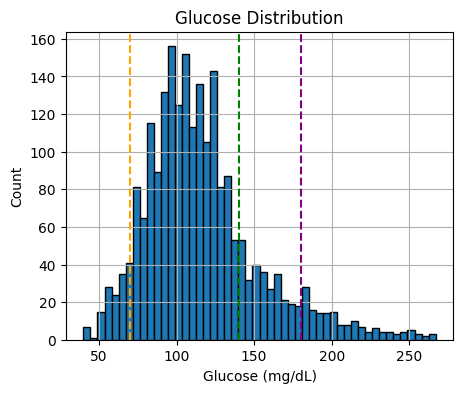

In [6]:
plt.figure(figsize=(5,4))

plt.hist(pkl_glucose, bins=50, edgecolor="black")

plt.axvline(70, color="orange", linestyle="--")
plt.axvline(140, color="green", linestyle="--")
plt.axvline(180, color="purple", linestyle="--")

plt.xlabel("Glucose (mg/dL)"); plt.ylabel("Count"); plt.title("Glucose Distribution");
plt.grid(True); plt.show()

#### Percentage of Samples in Each Glucose Category

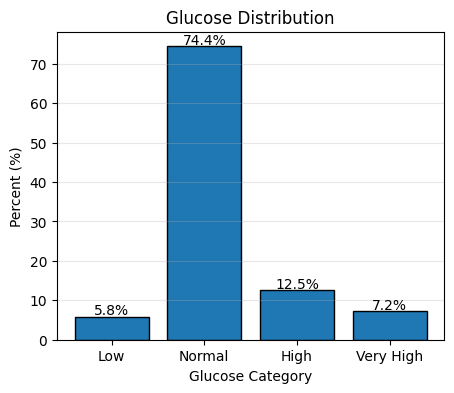

In [7]:
labels = [ "Low", "Normal", "High", "Very High"]

counts = []

for b in range(4):
    counts.append(np.sum(bg_bins == b))

counts = np.array(counts)

percentages = 100 * counts / counts.sum()

plt.figure(figsize=(5,4))

bars = plt.bar( labels, percentages, edgecolor="black")

plt.ylabel("Percent (%)"); plt.xlabel("Glucose Category"); plt.title("Glucose Distribution")
plt.grid(axis="y", alpha=0.3)

for bar, p in zip(bars, percentages):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{p:.1f}%",
        ha="center"
    )

plt.show()

#### Overall BG Distribution across clinical bins

In [8]:
for b in np.unique(bg_bins):
  vals3 = pkl_glucose[bg_bins == b]
  print(
      f"Bin {b:>2}: "
      f"min = {vals3.min():>6.1f}, "
      f"max = {vals3.max():>6.1f}, "
      f"count = {len(vals3)}"
  )

Bin  0: min =   40.0, max =   69.0, count = 130
Bin  1: min =   70.0, max =  139.0, count = 1654
Bin  2: min =  140.0, max =  179.0, count = 278
Bin  3: min =  180.0, max =  267.0, count = 161


### Stratified PKL-Based Train-Test Split

In [9]:
# =========================================================
# Stratified split on PKLs
# =========================================================
train_pkl_ids, test_pkl_ids = train_test_split(
    unique_pkl_ids,
    test_size=0.3,
    random_state=42,
    stratify=bg_bins
)

# =========================================================
# Create masks
# =========================================================
train_mask = np.isin(PKL_ID, train_pkl_ids)
test_mask = np.isin(PKL_ID, test_pkl_ids)

# =========================================================
# Final train/test split
# =========================================================
train_features = features[train_mask]
train_BG = BG[train_mask]
test_features = features[test_mask]
test_BG = BG[test_mask]

# =========================================================
# Print statistics
# =========================================================
print("Train samples:", len(train_features))
print("Test samples:", len(test_features))
print("Train PKLs:", len(train_pkl_ids))
print("Test PKLs:", len(test_pkl_ids))

# =========================================================
# Check BG distributions
# =========================================================
print("\nTrain BG statistics")
print("Mean:", np.mean(train_BG))
print("Std :", np.std(train_BG))
print("Min :", np.min(train_BG))
print("Max :", np.max(train_BG))

print("\nTest BG statistics")
print("Mean:", np.mean(test_BG))
print("Std :", np.std(test_BG))
print("Min :", np.min(test_BG))
print("Max :", np.max(test_BG))

Train samples: 20832
Test samples: 8596
Train PKLs: 1556
Test PKLs: 667

Train BG statistics
Mean: 118.15663
Std : 39.255447
Min : 40.0
Max : 267.0

Test BG statistics
Mean: 118.104935
Std : 38.382656
Min : 40.0
Max : 259.0


# **Configuration**

In [10]:
FEATURE_NUM = 50

RANDOM_STATE = 30

RF_PARAMS = {
    "n_estimators": 200,
    "max_samples": 0.87,
    "ccp_alpha": 0.0002,
    "min_samples_leaf": 2,
    "max_leaf_nodes": 30,
    "criterion": "squared_error",
    "random_state": RANDOM_STATE,
    "max_depth": 40,
    "min_samples_split": 4,
    "n_jobs": -1,
}

# **UFS / F-test**

In [11]:
from sklearn.feature_selection import SelectKBest, f_regression

def select_f_test(train_data, train_label, k):

    selector = SelectKBest(score_func=f_regression, k=k)

    selector.fit(train_data, train_label)

    selected_indices = selector.get_support(indices=True)

    # Sort selected features by F-score: highest → lowest
    sorted_indices = selected_indices[
        np.argsort(selector.scores_[selected_indices])[::-1]
    ]

    return sorted_indices

# **RFE**

In [12]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

def select_rfe(train_data, train_label, k):

    estimator = RandomForestRegressor(**RF_PARAMS)

    selector = RFE(estimator=estimator, n_features_to_select=k)

    selector.fit(train_data, train_label)

    selected_indices = np.where(selector.support_)[0]

    # Importance of selected features from the final estimator
    importances = selector.estimator_.feature_importances_

    # Sort: highest importance → lowest importance
    sorted_order = np.argsort(importances)[::-1]

    sorted_indices = selected_indices[sorted_order]

    return sorted_indices

# **L1-FS**

L1_FS (implemented by paper)

In [13]:
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler

def select_lasso(train_data, train_label, k):

    # Standardize features only for Lasso
    scaler = StandardScaler()

    train_data_scaled = scaler.fit_transform(train_data)

    # Lasso with cross-validation
    model = LassoCV(
        cv=5,
        alphas=100,
        eps=1e-6,
        tol=1e-4,
        max_iter=100000,
        random_state=RANDOM_STATE
    )

    model.fit(train_data_scaled, train_label)

    # Select features according to Lasso coefficients
    selector = SelectFromModel(
        model,
        prefit=True,
        max_features=k,
        threshold=-np.inf
    )

    selected_indices = selector.get_support(indices=True)

    coefficients = np.abs(model.coef_[selected_indices])
    sorted_indices = selected_indices[np.argsort(coefficients)[::-1]]


    print("alpha:", model.alpha_)
    print("coefficients:")
    print(model.coef_)

    print("selected:")
    print(selected_indices)

    print("abs coefficients:")
    print(np.abs(model.coef_[selected_indices]))

    print("sorted:")
    print(sorted_indices)

    return sorted_indices

L1_FS (custom implementation)

In [15]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV

def select_lasso(train_features, train_BG, train_PKL_ID, feature_num, random_state, n_alphas=100):

    # Create BG bins for stratified group cross-validation
    train_BG_bins = np.digitize(train_BG, bins=[70, 140, 180])

    # Create stratified group cross-validation splits
    cv_splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=random_state)

    cv_splits = list(cv_splitter.split(train_features, train_BG_bins, groups=train_PKL_ID))

    # Display information about each cross-validation fold
    for fold, (train_idx, val_idx) in enumerate(cv_splits):

        print(f"\nFold {fold + 1}")
        print("Train samples:", len(train_idx))
        print("Validation samples:", len(val_idx))
        print("Train PKLs:", len(np.unique(train_PKL_ID[train_idx])))
        print("Validation PKLs:", len(np.unique(train_PKL_ID[val_idx])))
        print("Validation BG bins:",
        np.bincount(train_BG_bins[val_idx], minlength=4))

    # Create the preprocessing and Lasso pipeline
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(max_iter=500000, tol=1e-4, random_state=random_state))
    ])

    # Generate candidate alpha values
    alphas = np.logspace(np.log10(5.735165596), np.log10(0.001), n_alphas)

    # Search for the best alpha using cross-validation
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid={"lasso__alpha": alphas},
        cv=cv_splits,
        scoring="neg_mean_squared_error",
        n_jobs=-1,
        return_train_score=True
    )

    # Fit all candidate models
    grid.fit(train_features, train_BG)

    # Display the best alpha and its CV performance
    print("\nBest alpha:", grid.best_params_["lasso__alpha"])
    print("Best CV MSE:", -grid.best_score_)

    # Get the final model trained with the best alpha
    best_model = grid.best_estimator_

    # Get Lasso coefficients from the final model
    coef = best_model.named_steps["lasso"].coef_

    print("Non-zero coefficients:", np.count_nonzero(coef))
    print("Max |coefficient|:", np.max(np.abs(coef)))

    # Display the best alpha values and their CV MSEs
    results = grid.cv_results_

    order = np.argsort(results["rank_test_score"])

    print("\nTop alpha values:")

    for i in order[:15]:

        alpha = results["param_lasso__alpha"][i]
        mse = -results["mean_test_score"][i]
        print(f"alpha = {float(alpha):.8f} | " f"CV MSE = {mse:.4f}")

    # Rank features according to the absolute value of their coefficients
    feature_order = np.argsort(np.abs(coef))[::-1]

    # Select the top k features
    top_k_indices = feature_order[:feature_num]

    print(f"\nTop {feature_num} features:")
    print(top_k_indices)

    # Display the selected feature indices and their coefficients
    for idx in top_k_indices:
        print(f"Feature {idx}: " f"coefficient = {coef[idx]:.6f}")

    return top_k_indices, best_model, coef, grid

# **Intersection**

In [14]:
def intersection_features(f_idx, rfe_idx, lasso_idx):

    # Convert feature indices to sets and find their intersection
    common_features = set(f_idx) & set(rfe_idx) & set(lasso_idx)

    # Convert back to a sorted NumPy array
    selected_indices = np.asarray(sorted(common_features), dtype=int)

    return selected_indices

# **Final Temporal Feature Selection and Intersection**

In [16]:
train_data = train_features; train_label = train_BG

f_idx = select_f_test(train_data, train_label, FEATURE_NUM)
rfe_idx = select_rfe(train_data, train_label, FEATURE_NUM)

train_PKL_ID = PKL_ID[train_mask]

lasso_idx, lasso_model, lasso_coef, lasso_grid = select_lasso(
    train_features=train_features,
    train_BG=train_BG,
    train_PKL_ID=train_PKL_ID,
    feature_num=FEATURE_NUM,
    random_state=RANDOM_STATE
)

selected_features = intersection_features(f_idx, rfe_idx,lasso_idx)


Fold 1
Train samples: 16517
Validation samples: 4315
Train PKLs: 1244
Validation PKLs: 312
Validation BG bins: [ 267 3113  554  381]

Fold 2
Train samples: 16630
Validation samples: 4202
Train PKLs: 1246
Validation PKLs: 310
Validation BG bins: [ 212 2974  672  344]

Fold 3
Train samples: 16649
Validation samples: 4183
Train PKLs: 1244
Validation PKLs: 312
Validation BG bins: [ 284 3054  593  252]

Fold 4
Train samples: 16738
Validation samples: 4094
Train PKLs: 1245
Validation PKLs: 311
Validation BG bins: [ 315 3021  430  328]

Fold 5
Train samples: 16794
Validation samples: 4038
Train PKLs: 1245
Validation PKLs: 311
Validation BG bins: [ 217 2824  520  477]

Best alpha: 0.003115634035528603
Best CV MSE: 1404.2698486328125
Non-zero coefficients: 64
Max |coefficient|: 37.405193

Top alpha values:
alpha = 0.00311563 | CV MSE = 1404.2698
alpha = 0.00340026 | CV MSE = 1404.2702
alpha = 0.00285484 | CV MSE = 1404.2703
alpha = 0.00371088 | CV MSE = 1404.2714
alpha = 0.00261587 | CV MSE = 

# **Final Temporal Features: Results and MATLAB Export**

In [17]:
# ============================================================
# Display feature-selection results
# ============================================================
print("\n========================================")
print("FINAL TEMPORAL FEATURE SELECTION")
print("========================================")
print("UFS selected features   :", f_idx)
print("RFE selected features   :", rfe_idx)
print("Lasso selected features :", lasso_idx)
print("----------------------------------------")
print("Common selected features:", selected_features)
print("Number of common features:", len(selected_features))

# ============================================================
# Check that at least one common feature exists
# ============================================================
if len(selected_features) == 0:
    raise ValueError("No common features were found among UFS, RFE, and Lasso.")

# ============================================================
# Apply selected temporal features to Train and Test
# ============================================================
temporal_train_feature = train_features[:, selected_features]
temporal_test_feature = test_features[:, selected_features]

# ============================================================
# Display final data shapes
# ============================================================
print("\nFinal dataset shapes:")
print("Temporal train feature:", temporal_train_feature.shape)
print("Temporal test feature :", temporal_test_feature.shape)
print("Train glucose         :", train_BG.shape)
print("Test glucose          :", test_BG.shape)

# ============================================================
# Save final temporal features
# ============================================================
selected_feature_names = [feature_headers[i] for i in selected_features]

output_file = "Subject1_Selected_Temporal_Feature.mat"

scio.savemat(output_file,
    {
        "temporal_train_feature": temporal_train_feature,
        "temporal_test_feature": temporal_test_feature,

        "train_glucose": train_BG,
        "test_glucose": test_BG,

        "train_pkl_ids": train_pkl_ids,
        "test_pkl_ids": test_pkl_ids,

        "selected_features": selected_features,

        # Names of selected features
        "selected_feature_names": np.array(selected_feature_names, dtype=object),

        # Save individual feature-selection results as well
        "ufs_selected_features": np.asarray(f_idx, dtype=int),
        "rfe_selected_features": np.asarray(rfe_idx, dtype=int),
        "lasso_selected_features": np.asarray(lasso_idx, dtype=int),
    }
)
print(f"\nResults saved to: {output_file}")


FINAL TEMPORAL FEATURE SELECTION
UFS selected features   : [62 38 47 37 51  7 36 11  6 10 14  1  8  3 35 31  0 43 16 32 24 39 44 52
 54 12 59 56 20 23 17 40 50 22 55 58 18 15 41  4 60 29 57 61 48  2 27 42
 46 25]
RFE selected features   : [28 38 62 35 24 37 59  3 14 60 11  4 56 12 47  8 31 18  0  9 40 16  6  7
 44 57 58 15 34  1 36 32 23 42 51 61  5  2 45 10 43 17 41 19 50 33 13 29
 27 20]
Lasso selected features : [ 5 45  7 61 40  6 24 56 14  1  0 47 15 59 44 60 16 10 57 36  2  9 11 51
 35 62 32 52  4 13 63 12 42 19 33 18 20 46 28 43 38 55 21  3 50 23 30 22
 49 34]
----------------------------------------
Common selected features: [ 0  1  2  3  4  6  7 10 11 12 14 15 16 18 20 23 24 32 35 36 38 40 42 43
 44 47 50 51 56 57 59 60 61 62]
Number of common features: 34

Final dataset shapes:
Temporal train feature: (20832, 34)
Temporal test feature : (8596, 34)
Train glucose         : (20832,)
Test glucose          : (8596,)

Results saved to: Subject1_Selected_Temporal_Feature.mat
